In [186]:
import pandas as pd

df_prc = pd.read_pickle("C:/Users/hp/Downloads/TER_M1_2025/data/ENQUETE_PRC_BC")
print(" Données PRC ")
print("Nombre de lignes :", len(df_prc))
print("Colonnes :", df_prc.columns.tolist())
print(df_prc.head(), "\n")
## ca prend presque 10 mins pour le loading de l'excel vu sa grande taille désolé :/
df_soins = pd.read_excel("C:/Users/hp/Downloads/TER_M1_2025/data/df_all_care_T0_no_filtered.xlsx")
print(" Données de Soins ")
print("Nombre de lignes :", len(df_soins))
print("Colonnes :", df_soins.columns.tolist())
print(df_soins.head())



 Données PRC 
Nombre de lignes : 930
Colonnes : ['ID_PATIENT', 'peur_recidive1']
   ID_PATIENT  peur_recidive1
0  1101100325               2
1  1101100717               3
2  1101100766               1
3  1102100494               2
4  1102101103               3 

 Données de Soins 
Nombre de lignes : 485287
Colonnes : ['ID_PATIENT', 'CODE', 'DAYS_SINCE_DIAG', 'TABLE_ORIGIN', 'Cons_Med_Gen', 'Cons_Spe', 'Mammographie', 'Echo_Mammaire', 'Irm_Mammaire', 'Echo_Abdominal', 'Thorax', 'Scintigraphie_Osseuse', 'Scanner', 'Osteodensitometrie', 'Evaluation_Cardiaque', 'Bilan_Bio', 'Fns', 'Bilan_Hepatique', 'Bilan_Lipidique', 'Ca_15_3', 'Tep_Scan', 'Echo_pelv', 'Echo_endometre', 'Dosage_calcium', 'Dosage_phosphore', 'Dosage_pholphocalcique', 'Cons_gyneco', 'RT', 'HT', 'Tamoxifen', 'Anti_arom', 'GnrH_ago', 'CT', 'Mastectomie', 'Mastectomie_part', 'SURG', 'T0', 'TREATMENT_TYPE']
   ID_PATIENT     CODE  DAYS_SINCE_DIAG TABLE_ORIGIN  Cons_Med_Gen  Cons_Spe  \
0  3104503184  D01AC12                0   

In [109]:
df_prc = pd.read_pickle("C:/Users/hp/Downloads/TER_M1_2025/data/ENQUETE_PRC_BC")
print(" Données PRC ")
print("Nombre de lignes :", len(df_prc))
print("Colonnes :", df_prc.columns.tolist())
print(df_prc.head(), "\n")

 Données PRC 
Nombre de lignes : 930
Colonnes : ['ID_PATIENT', 'peur_recidive1']
   ID_PATIENT  peur_recidive1
0  1101100325               2
1  1101100717               3
2  1101100766               1
3  1102100494               2
4  1102101103               3 



In [185]:
df_soins.to_csv("df_soins.csv", index=False)


In [187]:
df_soins = pd.read_csv("df_soins.csv")
df_soins.columns


Index(['ID_PATIENT', 'CODE', 'DAYS_SINCE_DIAG', 'TABLE_ORIGIN', 'Cons_Med_Gen',
       'Cons_Spe', 'Mammographie', 'Echo_Mammaire', 'Irm_Mammaire',
       'Echo_Abdominal', 'Thorax', 'Scintigraphie_Osseuse', 'Scanner',
       'Osteodensitometrie', 'Evaluation_Cardiaque', 'Bilan_Bio', 'Fns',
       'Bilan_Hepatique', 'Bilan_Lipidique', 'Ca_15_3', 'Tep_Scan',
       'Echo_pelv', 'Echo_endometre', 'Dosage_calcium', 'Dosage_phosphore',
       'Dosage_pholphocalcique', 'Cons_gyneco', 'RT', 'HT', 'Tamoxifen',
       'Anti_arom', 'GnrH_ago', 'CT', 'Mastectomie', 'Mastectomie_part',
       'SURG', 'T0', 'TREATMENT_TYPE'],
      dtype='object')

In [188]:
# Liste des actes que tu veux dédupliquer par jour
actes_suivi = [
    "Cons_Spe", "Mammographie", "Echo_Mammaire", "Irm_Mammaire",
    "Fns", "Ca_15_3", "Bilan_Hepatique", "Bilan_Lipidique",
    "Echo_pelv", "Echo_endometre", "Osteodensitometrie", "Dosage_pholphocalcique"
]

# Grouper par ID_PATIENT + DAYS_SINCE_DIAG et prendre le max pour chaque acte
df_soins_dedoublonne = (
    df_soins
    .groupby(["ID_PATIENT", "DAYS_SINCE_DIAG"], as_index=False)[actes_suivi]
    .max()
)

# Fusionner avec les autres colonnes non médicales (ex: CODE, TABLE_ORIGIN...) si tu veux les garder
colonnes_non_actes = [col for col in df_soins.columns if col not in actes_suivi]
df_infos = df_soins[colonnes_non_actes].drop_duplicates(subset=["ID_PATIENT", "DAYS_SINCE_DIAG"])

# Merge propre
df_soins_clean = pd.merge(df_soins_dedoublonne, df_infos, on=["ID_PATIENT", "DAYS_SINCE_DIAG"], how="left")


In [189]:
def recoder_prc(classe):
    if classe in [1, 2]:
        return 0  
    elif classe == 3:
        return 1  
    else:
        return None  

df_prc['PRC'] = df_prc['peur_recidive1'].apply(recoder_prc)

In [190]:
df_prc.head(20)

,ID_PATIENT,peur_recidive1,PRC
0,1101100325,2,0
1,1101100717,3,1
2,1101100766,1,0
3,1102100494,2,0
4,1102101103,3,1
5,1102101659,2,0
6,1102102186,3,1
7,1103100275,1,0
8,1103101510,1,0
9,1103102437,2,0


In [191]:
df_prc = df_prc[['ID_PATIENT', 'PRC']]


In [192]:
df_prc.head(5 )

,ID_PATIENT,PRC
0,1101100325,0
1,1101100717,1
2,1101100766,0
3,1102100494,0
4,1102101103,1


In [193]:
df_merged = df_soins_clean.merge(df_prc, on="ID_PATIENT", how="inner")


In [194]:
df_merged.head(900)

,ID_PATIENT,DAYS_SINCE_DIAG,Cons_Spe,Mammographie,Echo_Mammaire,Irm_Mammaire,Fns,Ca_15_3,Bilan_Hepatique,Bilan_Lipidique,...,Tamoxifen,Anti_arom,GnrH_ago,CT,Mastectomie,Mastectomie_part,SURG,T0,TREATMENT_TYPE,PRC
0,1101100325,15,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,254,"CT, HT, RT, SURG",0
1,1101100325,18,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,254,"CT, HT, RT, SURG",0
2,1101100325,20,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,254,"CT, HT, RT, SURG",0
3,1101100325,21,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,254,"CT, HT, RT, SURG",0
4,1101100325,36,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,254,"CT, HT, RT, SURG",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,1102101659,249,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,281,"CT, HT, RT, SURG",0
896,1102101659,251,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,281,"CT, HT, RT, SURG",0
897,1102101659,252,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,281,"CT, HT, RT, SURG",0
898,1102101659,255,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,281,"CT, HT, RT, SURG",0


In [195]:
df_merged= df_merged.drop(columns=["TREATMENT_TYPE"])


In [196]:
print("Nombre de patientes uniques :", df_merged['ID_PATIENT'].nunique())


Nombre de patientes uniques : 920


In [197]:
df_post_T0 = df_merged[df_merged["DAYS_SINCE_DIAG"] >= df_merged["T0"]]

In [198]:
df_post_T0

,ID_PATIENT,DAYS_SINCE_DIAG,Cons_Spe,Mammographie,Echo_Mammaire,Irm_Mammaire,Fns,Ca_15_3,Bilan_Hepatique,Bilan_Lipidique,...,HT,Tamoxifen,Anti_arom,GnrH_ago,CT,Mastectomie,Mastectomie_part,SURG,T0,PRC
62,1101100325,256,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,254,0
63,1101100325,286,1,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,254,0
64,1101100325,314,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,254,0
65,1101100325,319,1,0,0,0,0,0,0,0,...,1,0,1,0,0,0,0,0,254,0
66,1101100325,334,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,254,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148247,4309400482,1967,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,168,0
148248,4309400482,1978,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,168,0
148249,4309400482,1979,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,168,0
148250,4309400482,1985,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,168,0


In [199]:
len(set(df_post_T0[df_post_T0["Bilan_Lipidique"] > 0].ID_PATIENT))
len(set(df_post_T0[df_post_T0["Bilan_Hepatique"] > 0].ID_PATIENT))

869

In [200]:
df_post_T0["mois_depuis_T0"] = ((df_post_T0["DAYS_SINCE_DIAG"] - df_post_T0["T0"]) / 30).astype(int)


C:\Users\hp\AppData\Local\Temp\ipykernel_7984\1400350702.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [201]:
# Liste des actes médicaux suivis
actes_suivi = [
    "Cons_Spe",
    "Mammographie", "Echo_Mammaire", "Irm_Mammaire",
    "Fns", "Ca_15_3",
    "Bilan_Hepatique", "Bilan_Lipidique",
    "Echo_pelv", "Echo_endometre",       
    "Osteodensitometrie",               
    "Dosage_pholphocalcique"            
]

# Fréquences recommandées pour chaque acte médical selon le PPS
frequences_actes = {
    ### cons_spe considérer 6 mois
    "Cons_Spe": 3,
    "Mammographie": 12,
    "Echo_Mammaire": 12,
    "Ca_15_3": 12,
    "Fns": 12,
    "Bilan_Hepatique": 12,
    "Bilan_Lipidique": 12,
    "Echo_pelv": 12,
    "Echo_endometre": 12,
    "Osteodensitometrie": [0, 24],
    "Dosage_pholphocalcique": [0, 24],
}


In [202]:
df_suivi_filtré = df_post_T0[df_post_T0[actes_suivi].sum(axis=1) >= 1]


In [203]:
print("Nombre d’actes post-T0 pertinents au suivi :", len(df_suivi_filtré))
print(df_suivi_filtré[["ID_PATIENT", "mois_depuis_T0", "PRC"] + actes_suivi].head())


Nombre d’actes post-T0 pertinents au suivi : 29847
    ID_PATIENT  mois_depuis_T0  PRC  Cons_Spe  Mammographie  Echo_Mammaire  \
62  1101100325               0    0         1             0              0   
63  1101100325               1    0         1             0              0   
64  1101100325               2    0         1             0              0   
65  1101100325               2    0         1             0              0   
66  1101100325               2    0         0             1              1   

    Irm_Mammaire  Fns  Ca_15_3  Bilan_Hepatique  Bilan_Lipidique  Echo_pelv  \
62             0    0        0                0                0          0   
63             0    0        0                1                0          0   
64             0    0        0                0                0          0   
65             0    0        0                0                0          0   
66             0    0        0                0                0          0   

    E

In [204]:
df_post_T0.isna().sum()


ID_PATIENT                0
DAYS_SINCE_DIAG           0
Cons_Spe                  0
Mammographie              0
Echo_Mammaire             0
Irm_Mammaire              0
Fns                       0
Ca_15_3                   0
Bilan_Hepatique           0
Bilan_Lipidique           0
Echo_pelv                 0
Echo_endometre            0
Osteodensitometrie        0
Dosage_pholphocalcique    0
CODE                      0
TABLE_ORIGIN              0
Cons_Med_Gen              0
Echo_Abdominal            0
Thorax                    0
Scintigraphie_Osseuse     0
Scanner                   0
Evaluation_Cardiaque      0
Bilan_Bio                 0
Tep_Scan                  0
Dosage_calcium            0
Dosage_phosphore          0
Cons_gyneco               0
RT                        0
HT                        0
Tamoxifen                 0
Anti_arom                 0
GnrH_ago                  0
CT                        0
Mastectomie               0
Mastectomie_part          0
SURG                

In [229]:

df_post_T0 = df_merged[df_merged["DAYS_SINCE_DIAG"] >= df_merged["T0"]].copy()

# 3. Recalculer mois depuis T0
df_post_T0["mois_depuis_T0"] = ((df_post_T0["DAYS_SINCE_DIAG"] - df_post_T0["T0"]) / 30).astype(int)

# 4. Remplir les éventuels NaN par 0 (sécurité)
df_post_T0[actes_suivi] = df_post_T0[actes_suivi].fillna(0)

# 5. Compter 1 seul acte par jour déjà garanti ➜ maintenant on groupe par patient
df_counts = df_post_T0.groupby("ID_PATIENT")[actes_suivi].sum().reset_index()

# 6. Durée de suivi en mois
duree_suivi = df_post_T0.groupby("ID_PATIENT")["mois_depuis_T0"].max().reset_index(name="duree_suivi_mois")

# 7. Format long
df_long = df_counts.melt(id_vars="ID_PATIENT", var_name="Acte", value_name="Nb_realisations")

# 8. Fusion avec durée
df_long = df_long.merge(duree_suivi, on="ID_PATIENT", how="left")
df_long = df_long[df_long["Acte"] != "Irm_Mammaire"].copy()


# 9. Ajout des fréquences PPS
df_long["Frequence_mois"] = df_long["Acte"].map(frequences_actes)


In [230]:
df_long.isna().sum()

ID_PATIENT          0
Acte                0
Nb_realisations     0
duree_suivi_mois    0
Frequence_mois      0
dtype: int64

In [231]:
df_long[df_long["Frequence_mois"].isna()]["Acte"].unique()


array([], dtype=object)

In [232]:
# Filtrer sur les deux actes
df_filtré = df_long[df_long["Acte"].isin(["Bilan_Hepatique", "Bilan_Lipidique"])]

# Compter le nombre de patients avec au moins 1 réalisation
freq_par_acte = df_filtré[df_filtré["Nb_realisations"] > 0].groupby("Acte")["ID_PATIENT"].nunique()

print(freq_par_acte)


Acte
Bilan_Hepatique    869
Bilan_Lipidique    834
Name: ID_PATIENT, dtype: int64


In [209]:
df_post_T0.to_csv("C:/Users/hp/Downloads/df_post_T0.csv", index=False)
df_suivi_filtré.to_csv("C:/Users/hp/Downloads/df_suivi_filtré.csv", index=False)


In [233]:
df_post_T0.columns

Index(['ID_PATIENT', 'DAYS_SINCE_DIAG', 'Cons_Spe', 'Mammographie',
       'Echo_Mammaire', 'Irm_Mammaire', 'Fns', 'Ca_15_3', 'Bilan_Hepatique',
       'Bilan_Lipidique', 'Echo_pelv', 'Echo_endometre', 'Osteodensitometrie',
       'Dosage_pholphocalcique', 'CODE', 'TABLE_ORIGIN', 'Cons_Med_Gen',
       'Echo_Abdominal', 'Thorax', 'Scintigraphie_Osseuse', 'Scanner',
       'Evaluation_Cardiaque', 'Bilan_Bio', 'Tep_Scan', 'Dosage_calcium',
       'Dosage_phosphore', 'Cons_gyneco', 'RT', 'HT', 'Tamoxifen', 'Anti_arom',
       'GnrH_ago', 'CT', 'Mastectomie', 'Mastectomie_part', 'SURG', 'T0',
       'PRC', 'mois_depuis_T0'],
      dtype='object')

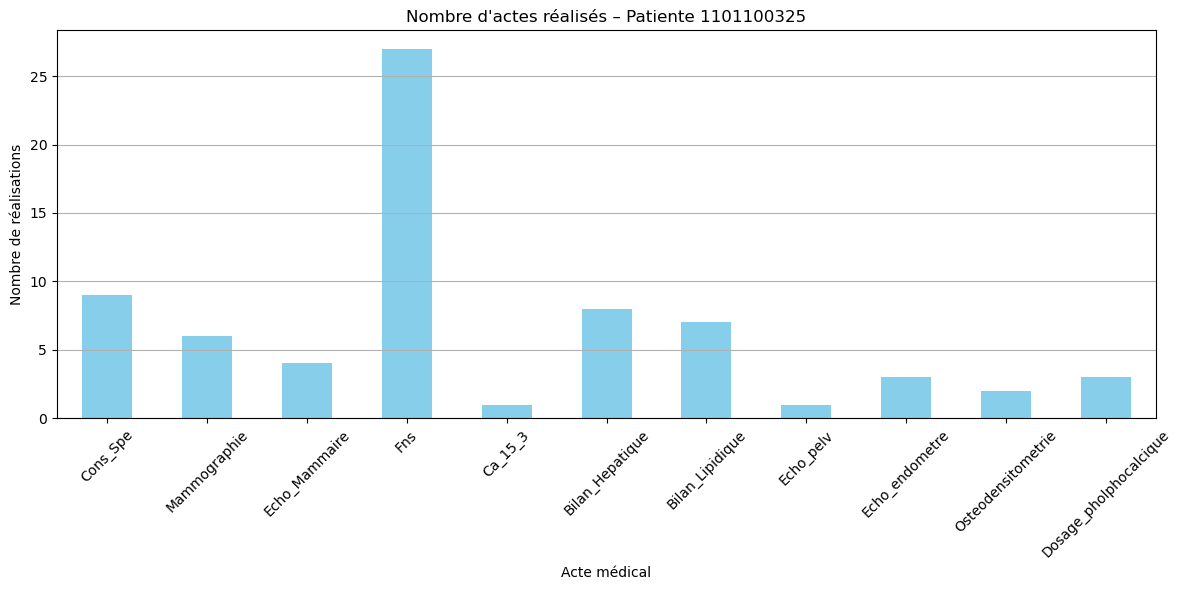

In [234]:
import matplotlib.pyplot as plt

id_exemple = df_long["ID_PATIENT"].iloc[0]

df_patient = df_long[df_long["ID_PATIENT"] == id_exemple]

df_plot = df_patient.set_index("Acte")["Nb_realisations"]

plt.figure(figsize=(12, 6))
df_plot.plot(kind="bar", color="skyblue")
plt.title(f"Nombre d'actes réalisés – Patiente {id_exemple}")
plt.ylabel("Nombre de réalisations")
plt.xlabel("Acte médical")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


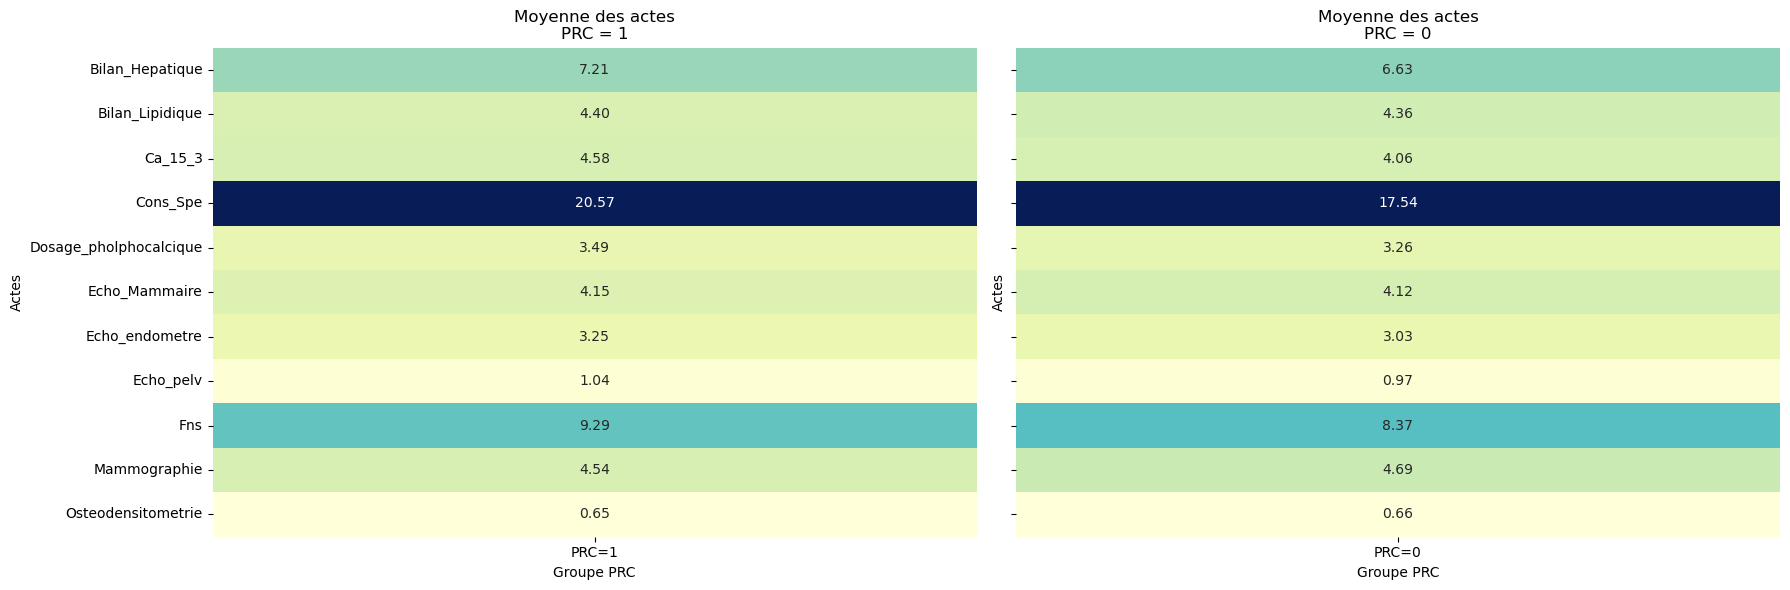

In [235]:
import seaborn as sns 
df_prc = df_merged[["ID_PATIENT", "PRC"]].drop_duplicates()
df_long = df_long.merge(df_prc, on="ID_PATIENT", how="left")
df_heatmap = df_long.groupby(["Acte", "PRC"])["Nb_realisations"].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

for prc_value, ax in zip([1, 0], axes):
    if prc_value in df_heatmap.columns:
        data = df_heatmap[[prc_value]].rename(columns={prc_value: f"PRC={prc_value}"})
        sns.heatmap(data, annot=True, cmap="YlGnBu", fmt=".2f", ax=ax, cbar=False)
        ax.set_title(f"Moyenne des actes\nPRC = {prc_value}")
        ax.set_xlabel("Groupe PRC")
        ax.set_ylabel("Actes")

plt.tight_layout()
plt.show()

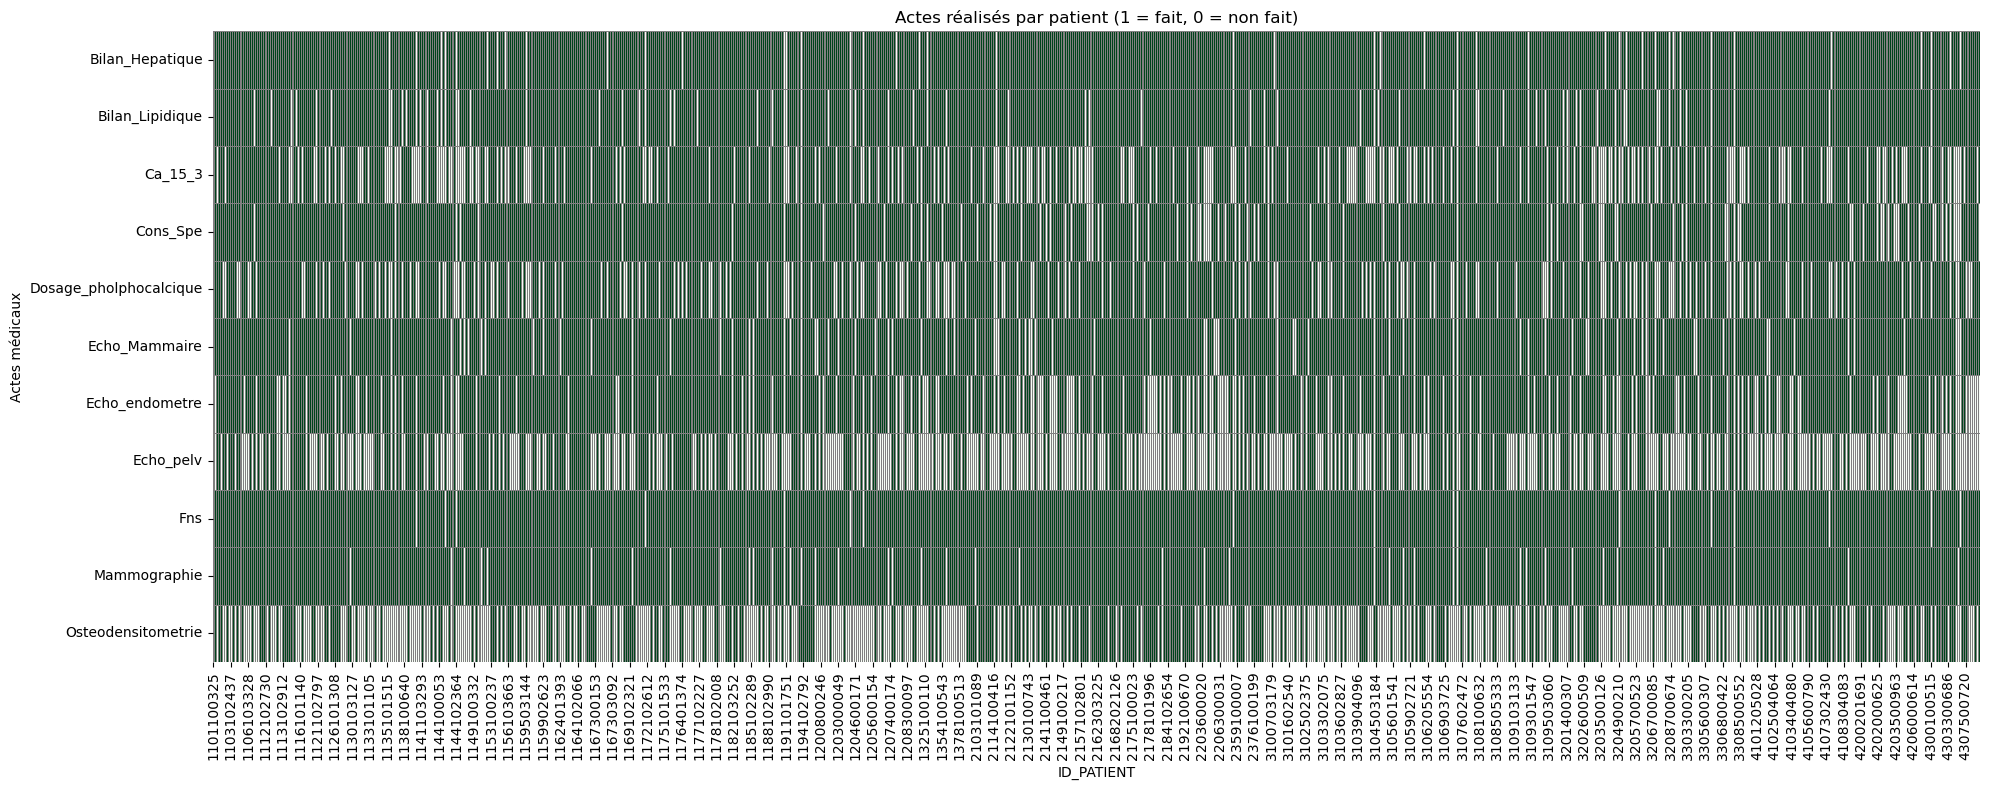

In [236]:
# Étape 1 : transformer en binaire
df_binaire = df_long.copy()
df_binaire["fait"] = (df_binaire["Nb_realisations"] > 0).astype(int)

# Étape 2 : pivot : lignes = actes, colonnes = patients
df_matrix = df_binaire.pivot(index="Acte", columns="ID_PATIENT", values="fait").fillna(0)

# Étape 3 : heatmap
plt.figure(figsize=(min(20, 0.3 * len(df_matrix.columns)), 8))  # auto-fit largeur
sns.heatmap(df_matrix, cmap="Greens", cbar=False, linewidths=0.5, linecolor='gray')

plt.title("Actes réalisés par patient (1 = fait, 0 = non fait)")
plt.xlabel("ID_PATIENT")
plt.ylabel("Actes médicaux")
plt.tight_layout()
plt.show()


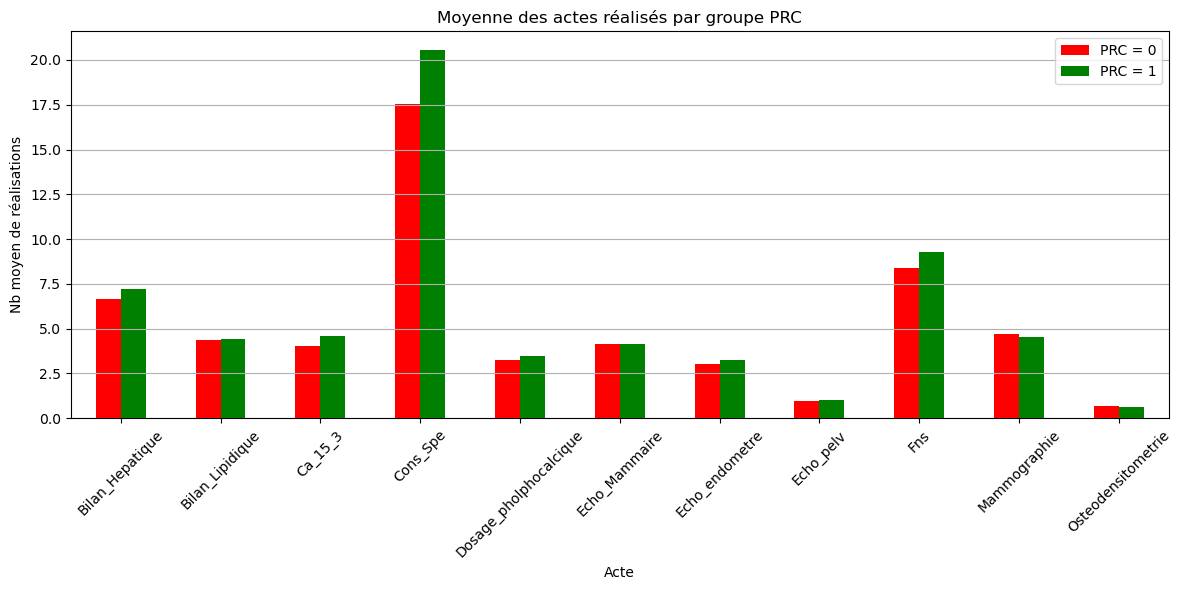

In [237]:
df_moyennes = df_long.groupby(["Acte", "PRC"])["Nb_realisations"].mean().unstack()
df_moyennes.plot(kind="bar", figsize=(12, 6), color=["red", "green"])
plt.title("Moyenne des actes réalisés par groupe PRC")
plt.ylabel("Nb moyen de réalisations")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.legend(["PRC = 0", "PRC = 1"])
plt.tight_layout()
plt.show()


In [238]:
# Voir les moyennes directement dans un tableau
df_debug = df_long.groupby(["Acte", "PRC"])["Nb_realisations"].mean().reset_index()

# Filtrer uniquement les deux actes en question
df_debug[df_debug["Acte"].isin(["Bilan_Hepatique", "Bilan_Lipidique"])]


,Acte,PRC,Nb_realisations
0,Bilan_Hepatique,0,6.628838
1,Bilan_Hepatique,1,7.214286
2,Bilan_Lipidique,0,4.364486
3,Bilan_Lipidique,1,4.398810


In [239]:
df_long[df_long["Nb_realisations"] > 0].groupby("Acte")["ID_PATIENT"].nunique().sort_values(ascending=False)


Acte
Fns                       897
Bilan_Hepatique           869
Mammographie              865
Bilan_Lipidique           834
Echo_Mammaire             819
Cons_Spe                  809
Echo_endometre            712
Dosage_pholphocalcique    681
Ca_15_3                   637
Osteodensitometrie        389
Echo_pelv                 383
Name: ID_PATIENT, dtype: int64

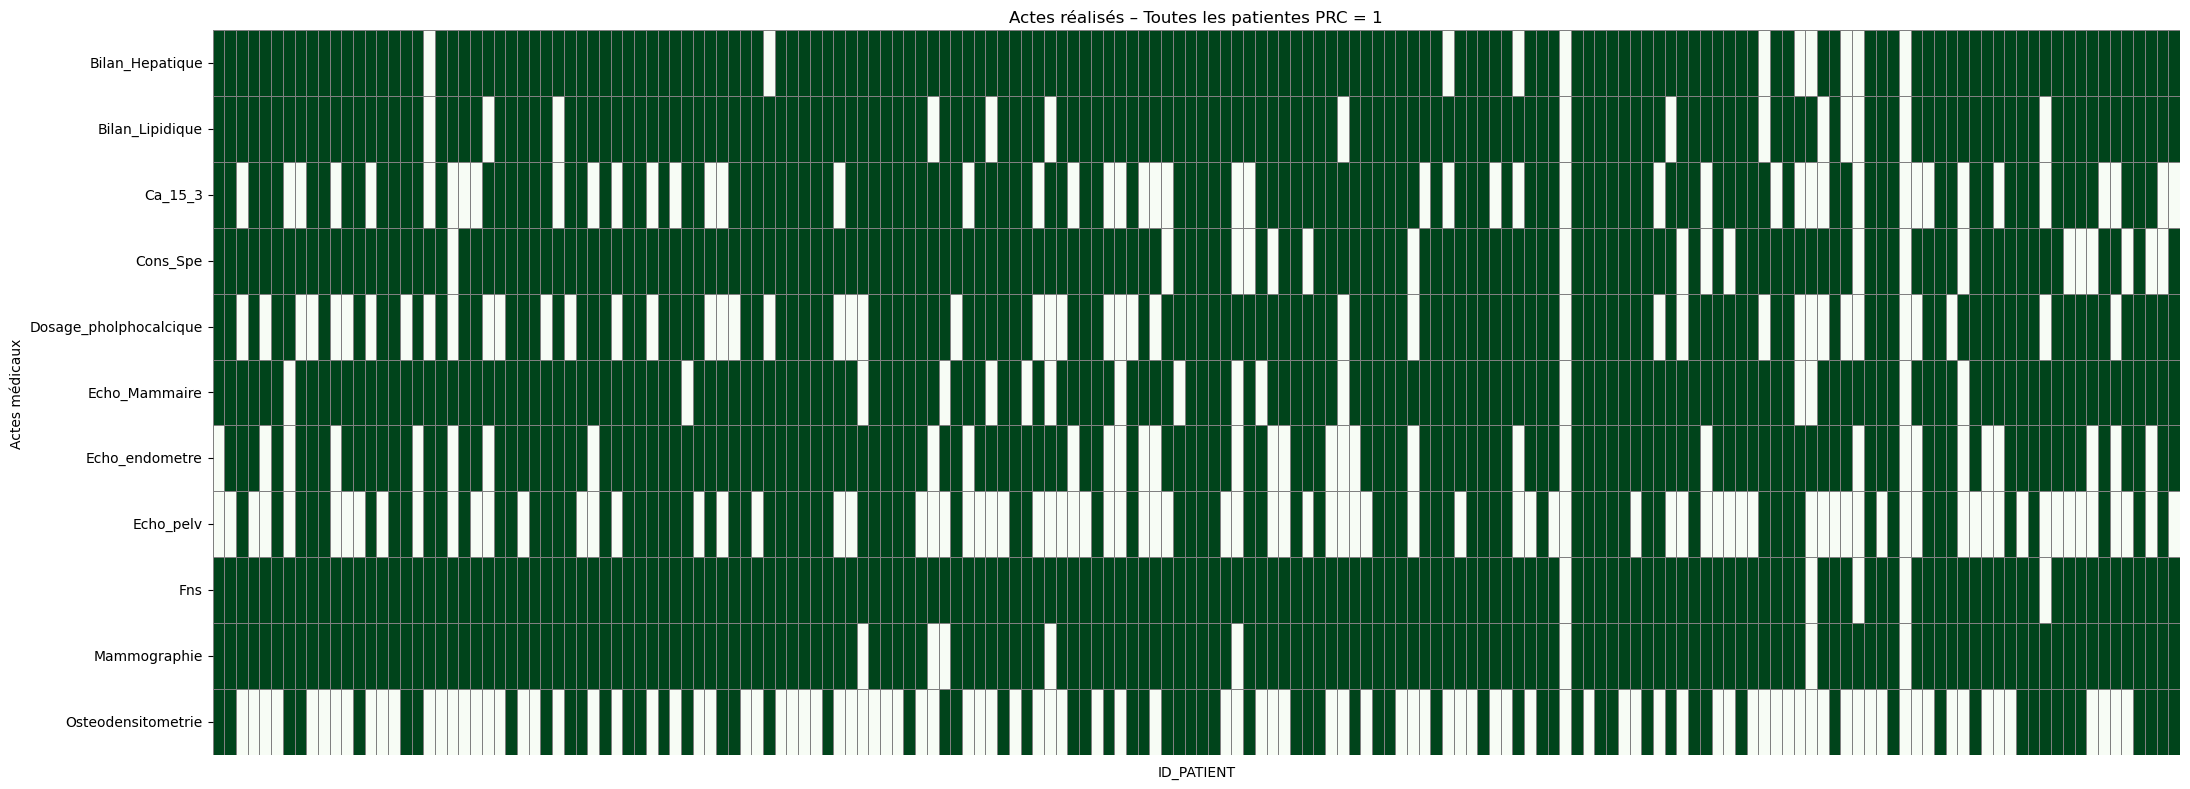

In [240]:
# PRC = 1
df_matrix_all = df_binaire.pivot(index="Acte", columns="ID_PATIENT", values="fait").fillna(0)

ids_prc1 = df_binaire[df_binaire["PRC"] == 1]["ID_PATIENT"].unique()
df_matrix_prc1 = df_matrix_all[[id_ for id_ in df_matrix_all.columns if id_ in ids_prc1]]

plt.figure(figsize=(min(22, 0.3 * len(df_matrix_prc1.columns)), 8))  # adapte la largeur
sns.heatmap(df_matrix_prc1, cmap="Greens", cbar=False, linewidths=0.5, linecolor='gray')
plt.title("Actes réalisés – Toutes les patientes PRC = 1")
plt.xlabel("ID_PATIENT")
plt.ylabel("Actes médicaux")
plt.xticks([], [])
plt.tight_layout()
plt.show()


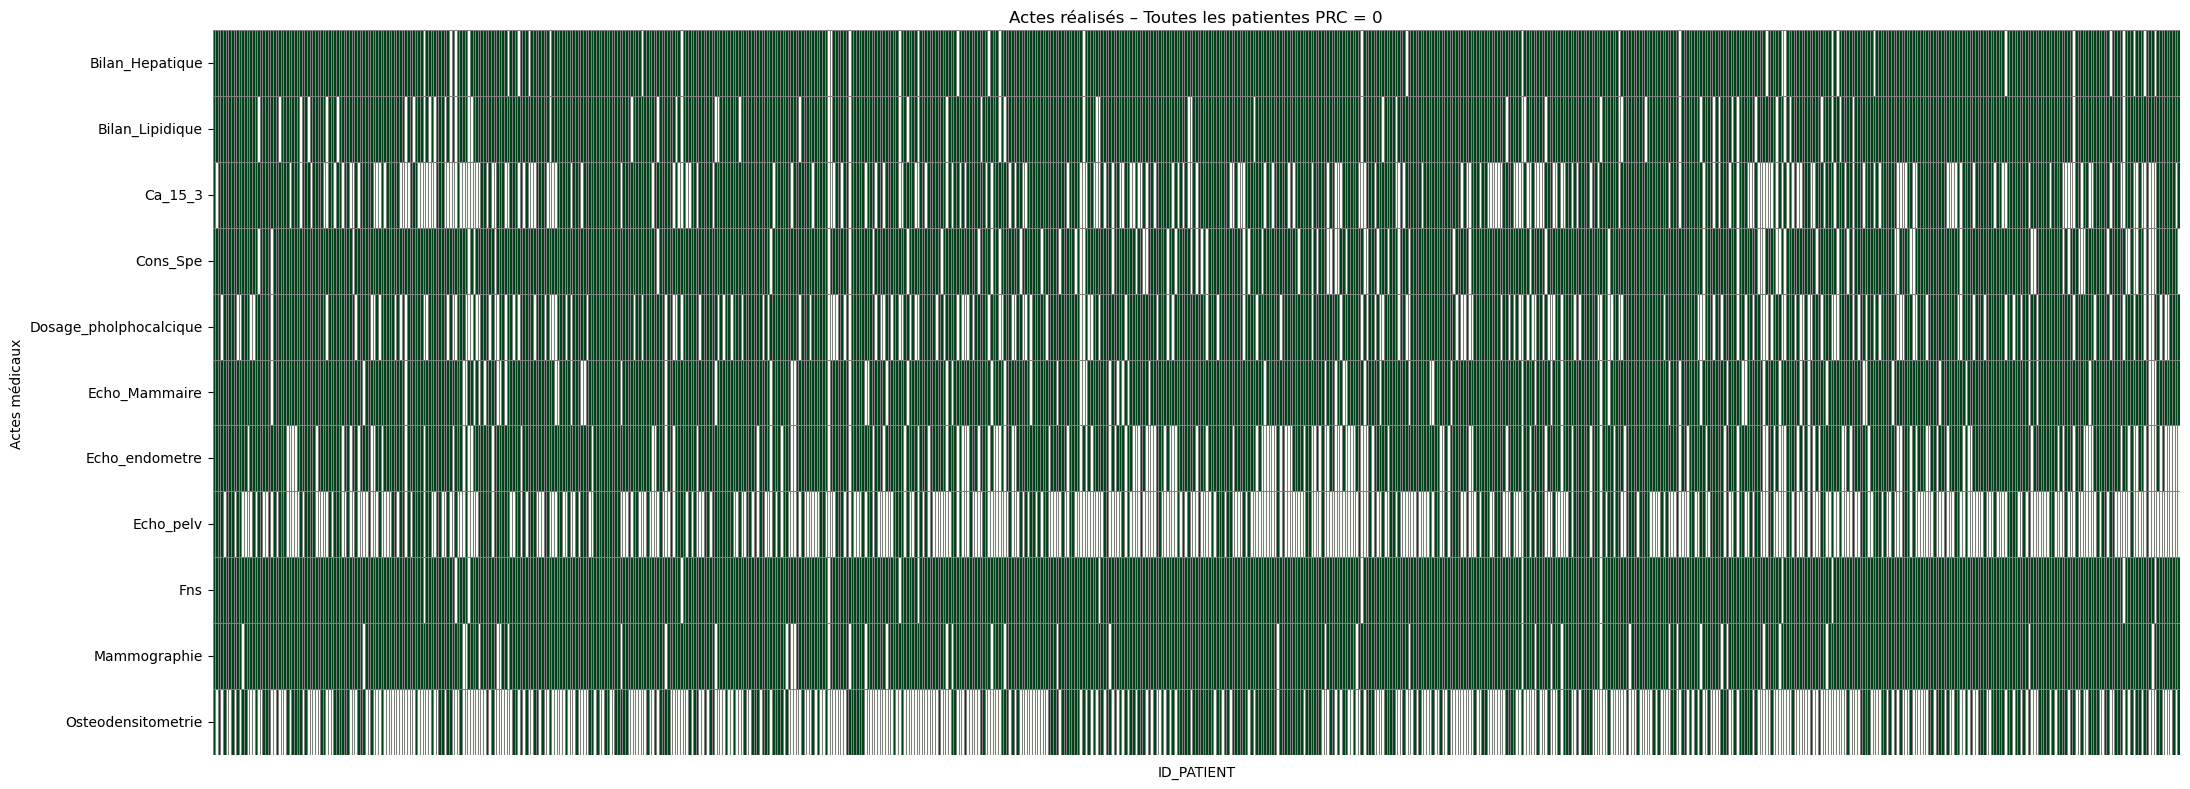

In [241]:
# PRC = 0
ids_prc0 = df_binaire[df_binaire["PRC"] == 0]["ID_PATIENT"].unique()
df_matrix_prc0 = df_matrix_all[[id_ for id_ in df_matrix_all.columns if id_ in ids_prc0]]

plt.figure(figsize=(min(22, 0.3 * len(df_matrix_prc0.columns)), 8))
sns.heatmap(df_matrix_prc0, cmap="Greens", cbar=False, linewidths=0.5, linecolor='gray')
plt.title("Actes réalisés – Toutes les patientes PRC = 0")
plt.xlabel("ID_PATIENT")
plt.ylabel("Actes médicaux")
plt.xticks([], [])
plt.tight_layout()
plt.show()


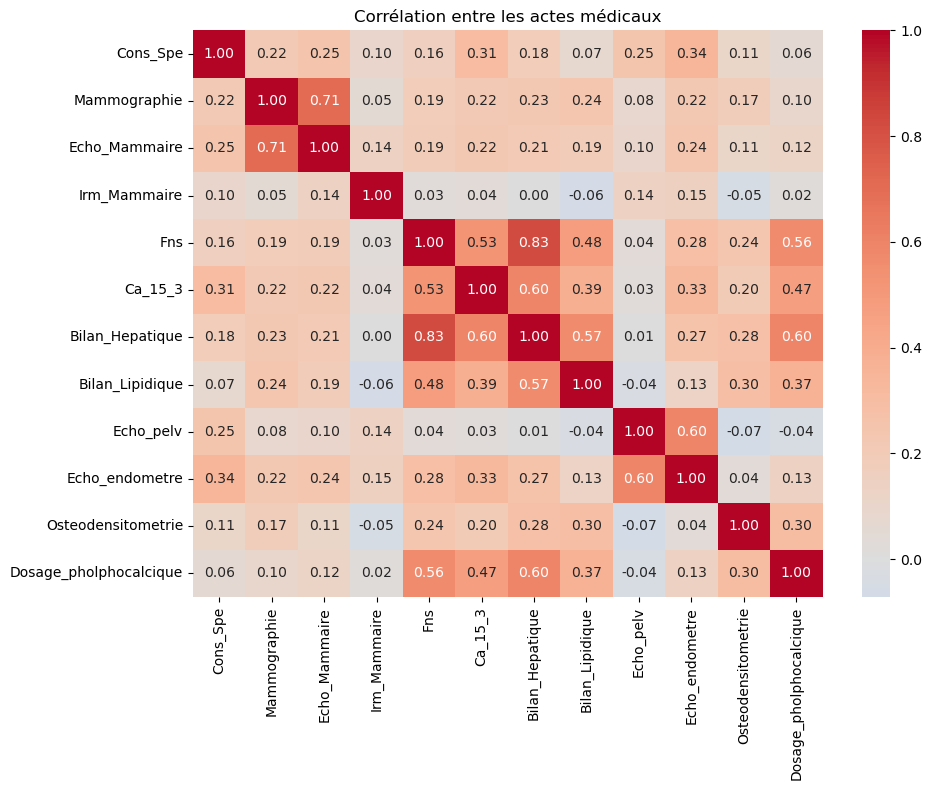

In [242]:
# Calcul de la corrélation entre les actes (quantité par patiente)
corr = df_counts[actes_suivi].corr()

# Affichage de la heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Corrélation entre les actes médicaux")
plt.tight_layout()
plt.show()


In [244]:
df_long.isna().sum()

ID_PATIENT          0
Acte                0
Nb_realisations     0
duree_suivi_mois    0
Frequence_mois      0
PRC                 0
dtype: int64

## Etude de Conformité avec les recommendations du PSP

In [245]:
def calculer_score_continu(row):
    freq = frequences_actes.get(row["Acte"])
    nb_realisations = row["Nb_realisations"]
    duree = row["duree_suivi_mois"]

    if freq is None:
        return None
    elif isinstance(freq, list):  # actes ponctuels
        attendus = len([m for m in freq if m <= duree])
        return min(nb_realisations / attendus, 1) if attendus > 0 else None
    else:  # actes réguliers
        attendus = int((duree + freq / 2) // freq)  # tolérance souple
        return min(nb_realisations / attendus, 1) if attendus > 0 else None
df_long["score_conformité"] = df_long.apply(calculer_score_continu, axis=1)


In [246]:
df_long.head(20)

,ID_PATIENT,Acte,Nb_realisations,duree_suivi_mois,Frequence_mois,PRC,score_conformité
0,1101100325,Cons_Spe,9,73,3,0,0.375000
1,1101100717,Cons_Spe,6,78,3,1,0.230769
2,1101100766,Cons_Spe,9,74,3,0,0.360000
3,1102100494,Cons_Spe,2,70,3,0,0.086957
4,1102101103,Cons_Spe,2,76,3,1,0.080000
5,1102101659,Cons_Spe,20,75,3,0,0.800000
6,1102102186,Cons_Spe,61,71,3,1,1.000000
7,1103100275,Cons_Spe,2,75,3,0,0.080000
8,1103101510,Cons_Spe,4,64,3,0,0.190476
9,1103102437,Cons_Spe,14,73,3,0,0.583333


In [247]:
# 1. Calcul des traitements actifs par patiente depuis df_merged
traitements = df_merged.groupby("ID_PATIENT")[["Tamoxifen", "Anti_arom"]].max().reset_index()

# 2. Intégrer les colonnes Tamoxifen / Anti_arom / CT dans df_long
df_long = df_long.merge(traitements, on="ID_PATIENT", how="left")


                            PRC_0      PRC_1  Différence PRC1 - PRC_0
Cons_Spe                17.538051  20.571429                 3.033378
Mammographie             4.691589   4.541667                -0.149922
Echo_Mammaire            4.122830   4.154762                 0.031931
Fns                      8.373832   9.285714                 0.911883
Ca_15_3                  4.057410   4.577381                 0.519971
Bilan_Hepatique          6.628838   7.214286                 0.585447
Bilan_Lipidique          4.364486   4.398810                 0.034324
Echo_pelv                1.418283   1.301075                -0.117207
Echo_endometre           3.831025   3.731183                -0.099842
Osteodensitometrie       1.183801   1.142857                -0.040943
Dosage_pholphocalcique   4.028037   4.688312                 0.660274


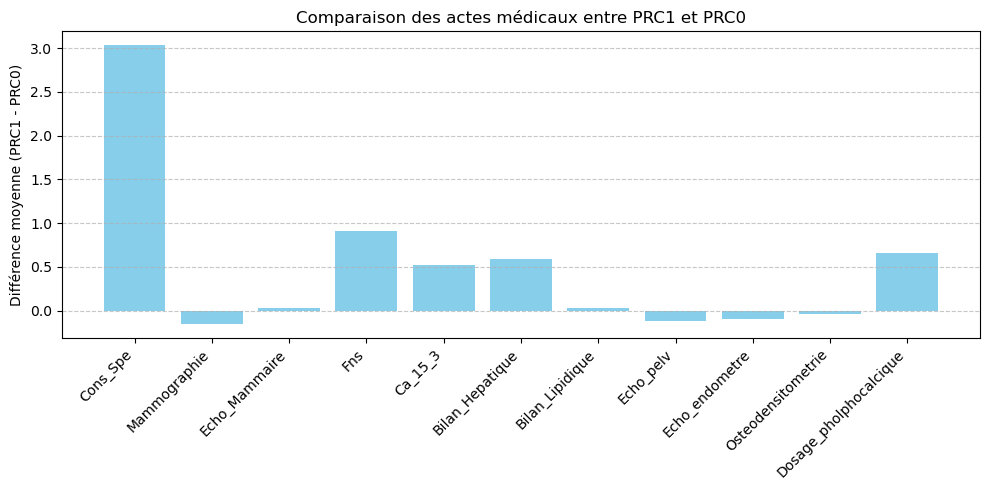

In [248]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Fonction adaptée à df_long
def moyenne_par_acte_conditionnelle_long(df_long, acte, condition_col=None):
    df_acte = df_long[df_long["Acte"] == acte]
    if condition_col:
        df_acte = df_acte[df_acte[condition_col] == 1]
    if df_acte.empty:
        return pd.DataFrame({f"PRC_0": [0], f"PRC_1": [0]}, index=[acte])
    
    moyennes = df_acte.groupby("PRC")["Nb_realisations"].mean().to_frame().T
    moyennes.columns = [f"PRC_{col}" for col in moyennes.columns]
    moyennes.index = [acte]
    return moyennes

# Dictionnaire des conditions spécifiques
actes_conditions = {
    "Cons_Spe": None,
    "Mammographie": None,
    "Echo_Mammaire": None,
    "Fns": None,
    "Ca_15_3": None,
    "Bilan_Hepatique": None,
    "Bilan_Lipidique": None,
    "Echo_pelv": "Tamoxifen",
    "Echo_endometre": "Tamoxifen",
    "Osteodensitometrie": "Anti_arom",
    "Dosage_pholphocalcique": "Anti_arom"
}

# Calcul des moyennes
moyennes_finales = []
for acte, condition in actes_conditions.items():
    moy = moyenne_par_acte_conditionnelle_long(df_long, acte, condition)
    moyennes_finales.append(moy)

df_moyennes_pps = pd.concat(moyennes_finales)

# Ajouter la différence PRC_1 - PRC_0
df_moyennes_pps["Différence PRC1 - PRC_0"] = df_moyennes_pps["PRC_1"] - df_moyennes_pps["PRC_0"]

# Affichage tableau
print(df_moyennes_pps)

# Sankey
labels = list(df_moyennes_pps.index) + ["PRC_0", "PRC_1"]
sources, targets, values = [], [], []

for i, acte in enumerate(df_moyennes_pps.index):
    sources += [i, i]
    targets += [len(df_moyennes_pps.index), len(df_moyennes_pps.index)+1]
    values += [df_moyennes_pps.loc[acte, "PRC_0"], df_moyennes_pps.loc[acte, "PRC_1"]]

fig = go.Figure(data=[go.Sankey(
    node=dict(label=labels, pad=15, thickness=20),
    link=dict(source=sources, target=targets, value=values)
)])
fig.show()

# Histogramme style "code initial"
plt.figure(figsize=(10, 5))
plt.bar(df_moyennes_pps.index, df_moyennes_pps["Différence PRC1 - PRC_0"], color="skyblue")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Différence moyenne (PRC1 - PRC0)")
plt.title("Comparaison des actes médicaux entre PRC1 et PRC0")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


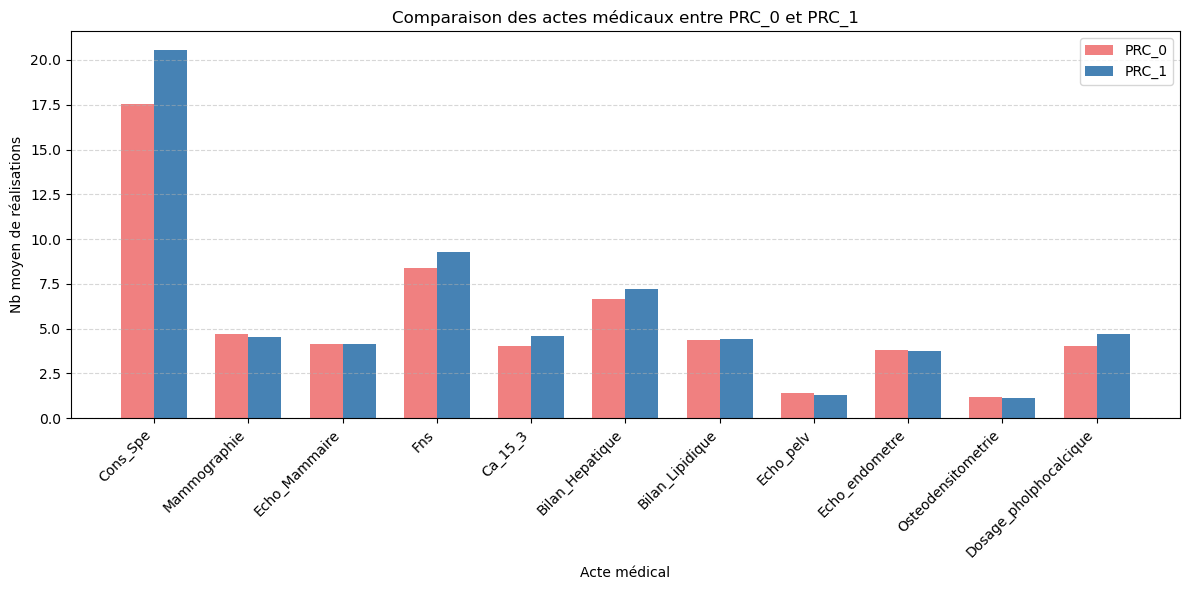

In [249]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
bar_width = 0.35
index = range(len(df_moyennes_pps))

plt.bar(index, df_moyennes_pps["PRC_0"], bar_width, label="PRC_0", color='lightcoral')
plt.bar([i + bar_width for i in index], df_moyennes_pps["PRC_1"], bar_width, label="PRC_1", color='steelblue')

plt.xlabel("Acte médical")
plt.ylabel("Nb moyen de réalisations")
plt.title("Comparaison des actes médicaux entre PRC_0 et PRC_1")
plt.xticks([i + bar_width / 2 for i in index], df_moyennes_pps.index, rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


Moyenne de conformité : 56.63%


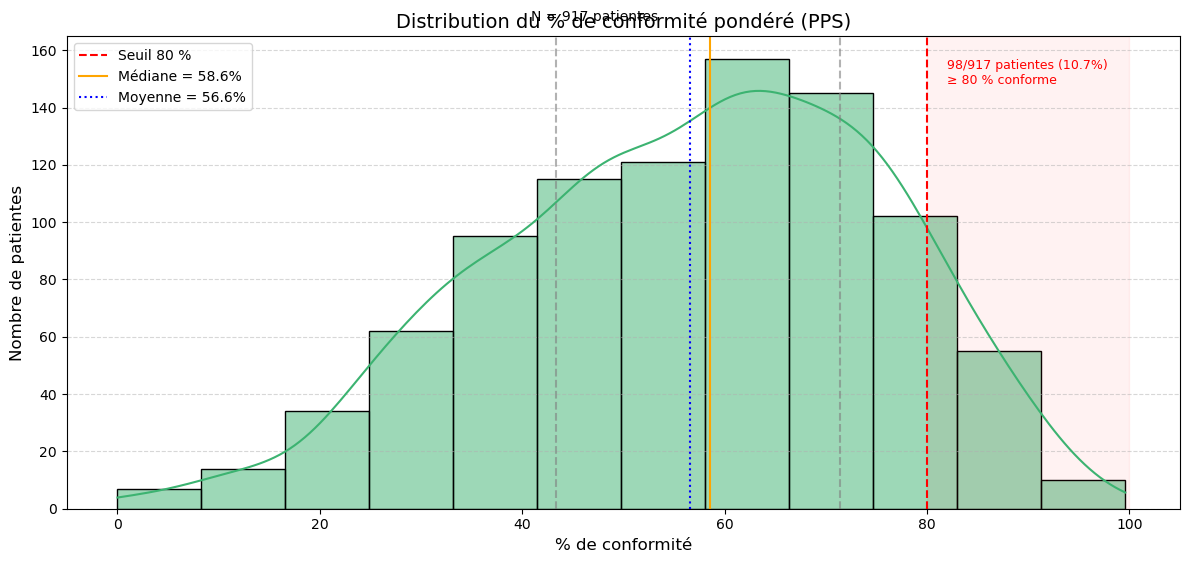

In [250]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcul du score de conformité par patient (en %)
df_scores = (
    df_long[~df_long["score_conformité"].isna()]
    .groupby("ID_PATIENT")["score_conformité"]
    .mean()
    .reset_index(name="pct_PPS_pondéré")
)
df_scores["pct_PPS_pondéré"] *= 100

# Affiche la moyenne
print(f"Moyenne de conformité : {df_scores['pct_PPS_pondéré'].mean():.2f}%")


# Statistiques descriptives
serie = df_scores["pct_PPS_pondéré"]
n = len(serie)
mean = serie.mean()
med = serie.median()
q1, q3 = serie.quantile([.25, .75])
n_ok = (serie >= 80).sum()

# Graphique
plt.figure(figsize=(12, 6))
sns.histplot(serie, bins=12, kde=True, color="mediumseagreen")

plt.axvline(80, ls="--", color="red", label="Seuil 80 %")
plt.axvline(med, ls="-", color="orange", label=f"Médiane = {med:.1f}%")
plt.axvline(mean, ls=":", color="blue", label=f"Moyenne = {mean:.1f}%")
plt.axvline(q1, ls="--", color="grey", alpha=.6)
plt.axvline(q3, ls="--", color="grey", alpha=.6)
plt.axvspan(80, 100, color="red", alpha=.05)

plt.text(82, plt.ylim()[1]*.9,
         f"{n_ok}/{n} patientes ({n_ok/n:.1%})\n≥ 80 % conforme",
         color="red", fontsize=9)

plt.title("Distribution du % de conformité pondéré (PPS)", fontsize=14)
plt.xlabel("% de conformité", fontsize=12)
plt.ylabel("Nombre de patientes", fontsize=12)
plt.suptitle(f"N = {n} patientes", y=0.93, fontsize=10)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


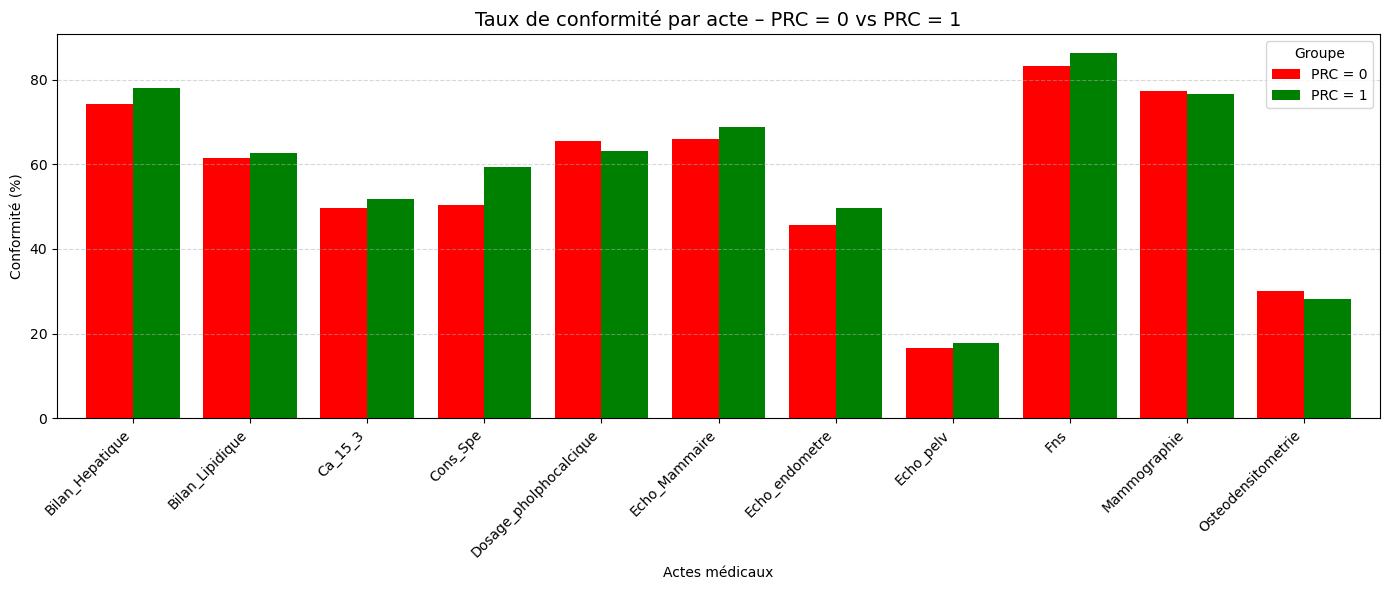

In [251]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calcul du pourcentage de conformité par acte et PRC
df_conformite_pct = (
    df_long[~df_long["score_conformité"].isna()]
    .groupby(["Acte", "PRC"])["score_conformité"]
    .mean()
    .unstack()
    .fillna(0) * 100
)

# Affichage du barplot
ax = df_conformite_pct.plot(kind="bar", figsize=(14, 6), width=0.8, color=["red", "green"])
plt.title("Taux de conformité par acte – PRC = 0 vs PRC = 1", fontsize=14)
plt.ylabel("Conformité (%)")
plt.xlabel("Actes médicaux")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(["PRC = 0", "PRC = 1"], title="Groupe")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd, plotly.graph_objects as go
from itertools import chain

def sankey_from_df(df_links, title):
    if df_links.empty:
        print(f"⚠️  Aucune donnée pour {title}")
        return
    labels = pd.Index(sorted(set(chain(df_links["source"], df_links["target"]))), name="label")
    codes = {lab: i for i, lab in enumerate(labels)}
    df_num = df_links.replace({"source": codes, "target": codes})
    fig = go.Figure(go.Sankey(
        arrangement="snap",
        node=dict(label=labels.tolist(), pad=15, thickness=15,
                  line=dict(color="black", width=0.5)),
        link=dict(source=df_num["source"], target=df_num["target"], value=df_num["value"])
    ))
    fig.update_layout(title_text=title, font_size=11, height=550, width=940)
    fig.show()


In [ ]:
df_long["score_pct"] = df_long.groupby("ID_PATIENT")["score_conformité"].transform(lambda x: 100 * x.mean())
df_long["score_band"] = pd.cut(df_long["score_pct"], bins=[0, 20, 40, 60, 80, 100],
                               labels=["0-20 %", "20-40 %", "40-60 %", "60-80 %", "80-100 %"],
                               right=False)

# Correction
links = (
    df_long.query("score_conformité == 1")
    .groupby(["Acte", "score_band"])
    .size()
    .reset_index(name="value")
    .rename(columns={"Acte": "source", "score_band": "target"})
)

sankey_from_df(links, "Actes ➜ score de conformité")


In [ ]:
# 1. Mapping actes → famille
family_map = {
    "Cons_Spe": "Consultation",
    "Mammographie": "Imagerie",
    "Echo_Mammaire": "Imagerie",
    "Irm_Mammaire": "Imagerie",
    "Fns": "Biologie",
    "Ca_15_3": "Biologie",
    "Bilan_Hepatique": "Biologie",
    "Bilan_Lipidique": "Biologie",
    "Echo_pelv": "Gynécologie",
    "Echo_endometre": "Gynécologie",
    "Osteodensitometrie": "Ostéo",
    "Dosage_pholphocalcique": "Ostéo"
}

# 2. Associer chaque acte à une famille
df_long["Famille"] = df_long["Acte"].map(family_map)

# 3. Score de conformité
df_long["score_pct"] = df_long.groupby("ID_PATIENT")["score_conformité"].transform(lambda x: 100 * x.mean())
df_long["score_band"] = pd.cut(
    df_long["score_pct"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=["0-20 %", "20-40 %", "40-60 %", "60-80 %", "80-100 %"],
    right=False
)

# 4. Liens Famille ➜ Niveau de conformité
links_family = (
    df_long.query("score_conformité == 1")
           .groupby(["Famille", "score_band"])
           .size()
           .reset_index(name="value")
           .rename(columns={"Famille": "source", "score_band": "target"})
)

# 5. Affichage Sankey
sankey_from_df(links_family, "Familles d'actes ➜ score de conformité")


ID_PATIENT             0
Acte                   0
Nb_realisations        0
duree_suivi_mois       0
Frequence_mois         0
PRC                    0
score_conformité      43
Tamoxifen              0
Anti_arom              0
Famille                0
score_pct              0
score_band             0
conforme_str        4180
dtype: int64

In [ ]:
df_long.columns

Index(['ID_PATIENT', 'Acte', 'Nb_realisations', 'duree_suivi_mois',
       'Frequence_mois', 'PRC', 'conforme', 'Tamoxifen', 'Anti_arom', 'CT',
       'score_pct', 'score_band', 'Famille'],
      dtype='object')

In [ ]:
# Diagramme 1 : Famille ➜ PRC
links_fam_prc = (
    df_long.query("score_conformité == 1")
           .groupby(["Acte", "PRC"])
           .size()
           .reset_index(name="value")
           .assign(PRC=lambda d: d["PRC"].map({0: "PRC Faible", 1: "PRC Élevée"}))
           .rename(columns={"Acte": "source", "PRC": "target"})
)

sankey_from_df(links_fam_prc, "Familles d'actes ➜ Niveau de peur de récidive")


In [ ]:
# Diagramme 3 : Acte ➜ Famille
links_acte_famille = (
    df_long[["Acte", "Famille"]]
    .drop_duplicates()
    .assign(value=1)
    .rename(columns={"Acte": "source", "Famille": "target"})
)

sankey_from_df(links_acte_famille, "Actes ➜ Familles d’actes")


In [ ]:
df_long["conforme_str"] = df_long["score_conformité"].map({1: "Conforme", 0: "Non conforme"})

links_conform = (
    df_long
    .groupby(["Acte", "conforme_str"])
    .size()
    .reset_index(name="value")
    .rename(columns={"Acte": "source", "conforme_str": "target"})
)

sankey_from_df(links_conform, "Actes ➜ Conformité")


In [ ]:
df_long.isna().sum()

ID_PATIENT             0
Acte                   0
Nb_realisations        0
duree_suivi_mois       0
Frequence_mois         0
PRC                    0
score_conformité      43
Tamoxifen              0
Anti_arom              0
Famille                0
score_pct              0
score_band             0
conforme_str        4180
dtype: int64

   ID_PATIENT  PRC  Tamoxifen  Anti_arom
0  1101100325    0          0          0
1  1101100717    1          0          0
2  1101100766    0          0          0
3  1102100494    0          0          0
4  1102101103    1          0          0
ID_PATIENT    0
PRC           0
Tamoxifen     0
Anti_arom     0
dtype: int64


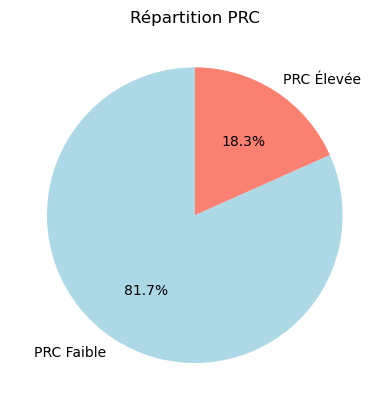

In [ ]:
df_unique_patients = (
    df_long[["ID_PATIENT", "PRC"]]
    .drop_duplicates()
    .merge(
        df_merged[["ID_PATIENT"] + traitements].drop_duplicates("ID_PATIENT"),
        on="ID_PATIENT",
        how="left"
    )
)
print(df_unique_patients.head())
print(df_unique_patients.isna().sum())


for trt in traitements:
    df_tmp = df_unique_patients[df_unique_patients[trt] == 1]
    
    links_trt_prc = (
        df_tmp.groupby([trt, "PRC"])
              .size()
              .reset_index(name="value")
              .assign(PRC=lambda d: d["PRC"].map({0: "PRC Faible", 1: "PRC Élevée"}))
              .assign(**{trt: trt})
              .rename(columns={trt: "source", "PRC": "target"})
    )

    sankey_from_df(links_trt_prc, f"{trt} ➜ Niveau de peur de récidive")
df_unique_patients["PRC"].map({0: "PRC Faible", 1: "PRC Élevée"}).value_counts().plot.pie(
    autopct="%1.1f%%", startangle=90, colors=["lightblue", "salmon"], ylabel="", title="Répartition PRC"
)
plt.show()


In [177]:
df_unique_patients["PRC"].value_counts()


0    749
1    168
Name: PRC, dtype: int64

In [181]:
# 1. Score global par patiente
df_scores = (
    df_long
    .groupby("ID_PATIENT")["score_conformité"]
    .mean()
    .reset_index(name="score_pct")
)

df_scores["score_pct"] *= 100
df_scores["score_band"] = pd.cut(
    df_scores["score_pct"],
    bins=[0, 20, 40, 60, 80, 100],
    labels=["0-20 %", "20-40 %", "40-60 %", "60-80 %", "80-100 %"],
    right=False
)

# 2. Ajouter PRC (1 ligne par patiente donc c’est safe)
df_scores = df_scores.merge(
    df_merged[["ID_PATIENT", "PRC"]].drop_duplicates("ID_PATIENT"),
    on="ID_PATIENT",
    how="left"
)

# 3. Sankey : Score ➜ PRC
links_score_prc = (
    df_scores
    .groupby(["score_band", "PRC"])
    .size()
    .reset_index(name="value")
    .assign(PRC=lambda d: d["PRC"].map({0: "PRC Faible", 1: "PRC Élevée"}))
    .rename(columns={"score_band": "source", "PRC": "target"})
)

sankey_from_df(links_score_prc, "Score de conformité (patient) ➜ Niveau de peur de récidive")


In [182]:
len(df_scores)


917

In [185]:
df_long.isna().sum()

ID_PATIENT             0
Acte                   0
Nb_realisations        0
duree_suivi_mois       0
Frequence_mois         0
PRC                    0
score_conformité      43
Tamoxifen              0
Anti_arom              0
Famille                0
score_pct              0
score_band             0
conforme_str        4180
nb_bin                 0
dtype: int64

In [184]:
# Ajouter une bande de nb de réalisations
df_long["nb_bin"] = pd.cut(df_long["Nb_realisations"], bins=[0, 1, 3, 6, 10, float("inf")],
                           labels=["1", "2-3", "4-6", "7-10", "10+"], right=False)

# Diagramme : Famille ➜ Nombre de réalisations
links_fam_nb = (
    df_long
    .groupby(["Acte", "nb_bin"])
    .size()
    .reset_index(name="value")
    .rename(columns={"Acte": "source", "nb_bin": "target"})
)

sankey_from_df(links_fam_nb, "Acte ➜ Nombre de réalisations")


## En gros pour cette partie 

#### Le graphe orange montre que chaque trimestre est rarement complet (score 0 à 2 dominant),

#### Le graphe bleu montre que malgré cela, certaines patientes parviennent à cumulativement respecter 4 à 6 critères sur 5 ans, ce qui est logique.

## Traitement d'Excès d'actes médicaux 

In [277]:
frequences_actes = {
    "Cons_Spe": 3,  # tous les 3 mois
    "Mammographie": 12,
    "Echo_Mammaire": 12,
    "Ca_15_3": 12,
    "Fns": 12,
    "Bilan_Hepatique": 12,
    "Bilan_Lipidique": 12,
    "Echo_pelv": 12,
    "Echo_endometre": 12,
    "Osteodensitometrie": [0, 24],  # ponctuel
    "Dosage_pholphocalcique": [0, 24],  # ponctuel
}



In [278]:
dependances = {
    "Echo_pelv": "Tamoxifen",
    "Osteodensitometrie": "Anti_arom",
    "Dosage_pholphocalcique": "Anti_arom"
}

# Calcul du seuil selon la durée de suivi
def seuil_par_duree(frequence_mois, duree_suivi):
    if frequence_mois is None:
        return float('inf')
    if isinstance(frequence_mois, list):  # actes ponctuels
        return 1 if duree_suivi >= frequence_mois[0] and duree_suivi <= frequence_mois[1] else 0
    return duree_suivi // frequence_mois + 1

# Détection de l'excès
def detecter_exces(row):
    acte = row["Acte"]
    if acte not in frequences_actes:
        return 0

    # Cas où l’acte dépend d’un traitement
    traitement_cond = dependances.get(acte)
    if traitement_cond and row.get(traitement_cond, 0) != 1:
        return 0

    seuil = seuil_par_duree(frequences_actes[acte], row["duree_suivi_mois"])
    return 1 if row["Nb_realisations"] > seuil else 0

# Application à ton DataFrame
df_long["excès"] = df_long.apply(detecter_exces, axis=1)
df_long["excès_str"] = df_long["excès"].map({1: "En excès", 0: "OK"})


In [254]:
df_nb_excès = df_long.groupby("ID_PATIENT")["excès"].sum().reset_index(name="nb_actes_en_excès")


ID_PATIENT           0
Acte                 0
Nb_realisations      0
duree_suivi_mois     0
Frequence_mois       0
PRC                  0
score_conformité    43
Tamoxifen            0
Anti_arom            0
excès                0
excès_str            0
PRC_str              0
dtype: int64

In [279]:
links_acte_exces = (
    df_long
    .groupby(["Acte", "excès_str"])
    .size()
    .reset_index(name="value")
    .rename(columns={"Acte": "source", "excès_str": "target"})
)

sankey_from_df(links_acte_exces, "Actes ➜ Statut d'excès de soins")


In [282]:
df_nb_excès = df_long.groupby("ID_PATIENT")["excès"].sum().reset_index(name="nb_actes_en_excès")
df_nb_excès["excès_patient"] = df_nb_excès["nb_actes_en_excès"].apply(lambda x: "En excès" if x > 0 else "OK")

df_links_patients_exces = (
    df_nb_excès
    .groupby("excès_patient")
    .size()
    .reset_index(name="value")
    .assign(source="Patient", target=lambda d: d["excès_patient"])
)

sankey_from_df(df_links_patients_exces, "Patient ➜ Excès de soins (au moins un)")


In [284]:
# Fusionner PRC avec les scores d'excès
df_nb_excès = df_nb_excès.merge(
    df_merged[["ID_PATIENT", "PRC"]].drop_duplicates("ID_PATIENT"),
    on="ID_PATIENT",
    how="left"
)

# Construire le lien Excès ➜ PRC
df_links_exces_prc = (
    df_nb_excès
    .groupby(["excès_patient", "PRC"])
    .size()
    .reset_index(name="value")
    .assign(PRC=lambda d: d["PRC"].map({0: "PRC Faible", 1: "PRC Élevée"}))
    .rename(columns={"excès_patient": "source", "PRC": "target"})
)

# Générer le Sankey
sankey_from_df(df_links_exces_prc, "Excès de soins ➜ Niveau de peur de récidive")



In [285]:
df_nb_excès.isna().sum()

ID_PATIENT           0
nb_actes_en_excès    0
excès_patient        0
PRC                  0
dtype: int64

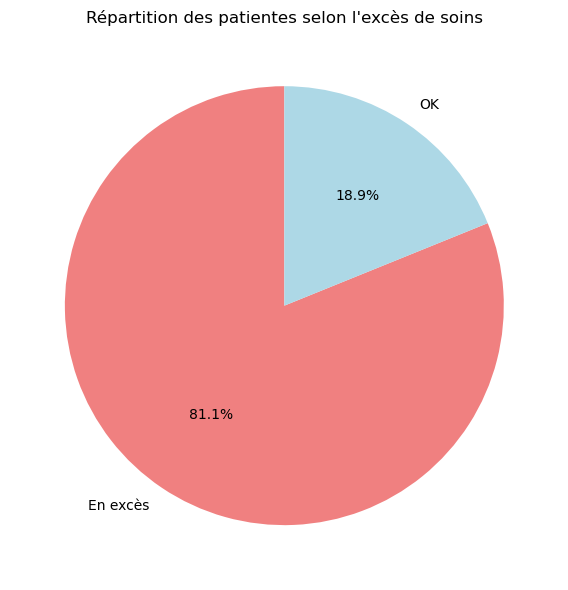

=== Test du Chi² ===
PRC              0    1
excès_patient          
En excès       600  144
OK             149   24

Statistique de test : 2.4644
p-value : 0.1164
Conclusion : Aucun lien significatif

=== Taux d'excès par acte ===
                        sum  count  % en excès
Acte                                          
Bilan_Hepatique         367    917        40.0
Bilan_Lipidique         187    917        20.4
Ca_15_3                 253    917        27.6
Cons_Spe                265    917        28.9
Dosage_pholphocalcique  326    917        35.6
Echo_Mammaire           104    917        11.3
Echo_endometre          108    917        11.8
Echo_pelv                10    917         1.1
Fns                     495    917        54.0
Mammographie             89    917         9.7
Osteodensitometrie      281    917        30.6


In [286]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# --- Données d'exemple (à adapter à ton contexte réel) ---
# df_long doit contenir : ID_PATIENT, Acte, excès
# df_merged doit contenir : ID_PATIENT, PRC
# Tu dois avoir une colonne 'excès' (0 ou 1)

# Étape 1 : Score d'excès par patiente
df_nb_excès = df_long.groupby("ID_PATIENT")["excès"].sum().reset_index(name="nb_actes_en_excès")
df_nb_excès["excès_patient"] = df_nb_excès["nb_actes_en_excès"].apply(lambda x: "En excès" if x > 0 else "OK")

# Étape 2 : Ajouter PRC par patiente
df_nb_excès = df_nb_excès.merge(
    df_merged[["ID_PATIENT", "PRC"]].drop_duplicates("ID_PATIENT"),
    on="ID_PATIENT",
    how="left"
)
df_nb_excès["PRC_str"] = df_nb_excès["PRC"].map({0: "PRC Faible", 1: "PRC Élevée"})

# ✅ CAMEMBERT Excès vs OK
plt.figure(figsize=(6, 6))
df_nb_excès["excès_patient"].value_counts().plot.pie(
    autopct="%1.1f%%",
    startangle=90,
    colors=["lightcoral", "lightblue"],
    ylabel=""
)
plt.title("Répartition des patientes selon l'excès de soins")
plt.tight_layout()
plt.show()

# ✅ TEST STATISTIQUE PRC ~ EXCÈS
contingency = pd.crosstab(df_nb_excès["excès_patient"], df_nb_excès["PRC"])
chi2, p_value, dof, expected = chi2_contingency(contingency)

print("=== Test du Chi² ===")
print(contingency)
print(f"\nStatistique de test : {chi2:.4f}")
print(f"p-value : {p_value:.4f}")
print(f"Conclusion : {'Lien significatif' if p_value < 0.05 else 'Aucun lien significatif'}")

# ✅ TABLEAU PAR ACTE : % EN EXCÈS
exces_par_acte = df_long.groupby("Acte")["excès"].agg(["sum", "count"])
exces_par_acte["% en excès"] = round(100 * exces_par_acte["sum"] / exces_par_acte["count"], 1)
print("\n=== Taux d'excès par acte ===")
print(exces_par_acte)


In [287]:
# Calculer le score d'excès pour chaque patiente : % des actes en excès
df_score_excès = (
    df_long.groupby("ID_PATIENT")
           .agg(score_excès=("excès", "mean"), PRC=("PRC", "first"))
           .reset_index()
)

from scipy.stats import shapiro, mannwhitneyu

# Groupes
groupe_0 = df_score_excès[df_score_excès["PRC"] == 0]["score_excès"]
groupe_1 = df_score_excès[df_score_excès["PRC"] == 1]["score_excès"]

# Test de normalité (échantillon de 500 si assez de données)
stat0, p0 = shapiro(groupe_0.sample(min(500, len(groupe_0)), random_state=1))
stat1, p1 = shapiro(groupe_1.sample(min(500, len(groupe_1)), random_state=1))

print(f"Test de Shapiro (PRC = 0) : p = {p0:.4f} → {'non normale' if p0 < 0.05 else 'normale'}")
print(f"Test de Shapiro (PRC = 1) : p = {p1:.4f} → {'non normale' if p1 < 0.05 else 'normale'}")

# Test de Mann-Whitney
stat, p = mannwhitneyu(groupe_0, groupe_1, alternative='two-sided')
print(f"\nTest de Mann-Whitney : U = {stat:.0f}, p = {p:.4f}")

# Méditation descriptive
print(f"Médiane score d’excès (PRC = 0) : {groupe_0.median():.2f}")
print(f"Médiane score d’excès (PRC = 1) : {groupe_1.median():.2f}")


Test de Shapiro (PRC = 0) : p = 0.0000 → non normale
Test de Shapiro (PRC = 1) : p = 0.0000 → non normale

Test de Mann-Whitney : U = 58099, p = 0.1165
Médiane score d’excès (PRC = 0) : 0.18
Médiane score d’excès (PRC = 1) : 0.27


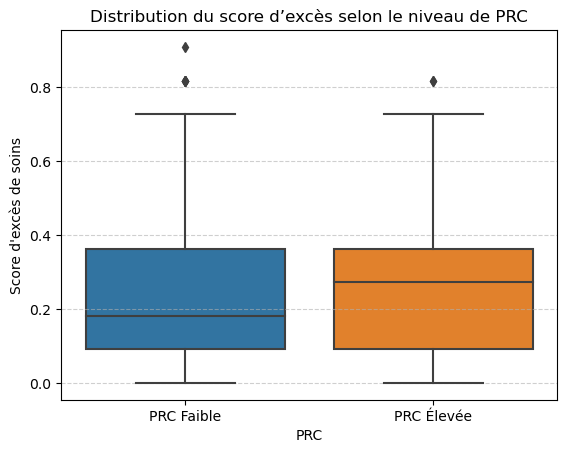

In [288]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df_score_excès, x="PRC", y="score_excès")
plt.xticks([0, 1], ["PRC Faible", "PRC Élevée"])
plt.ylabel("Score d'excès de soins")
plt.title("Distribution du score d’excès selon le niveau de PRC")
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()


### Pourquoi le score d’excès ?

Le score d’excès synthétise le nombre d’actes réalisés au-delà des seuils recommandés par le protocole PPS. Il permet d’identifier une possible surmédicalisation. Nous l’avons utilisé pour évaluer si le statut PRC est associé à un suivi potentiellement plus intensif que recommandé.

### Choix du test

Le test de Shapiro-Wilk montre que `score_excès` ne suit pas une distribution normale. Par conséquent, nous utilisons le test de Mann-Whitney U pour Évaluer si l'une des deux distributions tend à produire des valeurs plus grandes que l'autre.



### Résultat

Nous avons comparé le score d’excès de soins entre patientes ayant une peur de récidive faible (PRC=0) et élevée (PRC=1).
Les tests de normalité (Shapiro-Wilk) indiquent des distributions non normales.
Le test de Mann-Whitney ne révèle aucune différence significative (p = 0.1625).
La médiane du score d’excès est identique dans les deux groupes (0.42), ce qui suggère que la peur de récidive n'est pas associée à un excès de soins significativement plus élevé.


In [271]:
# 1. Score de conformité par patiente
df_score_conformité = (
    df_long.groupby("ID_PATIENT")
           .agg(score_conformité=("score_conformité", "mean"), PRC=("PRC", "first"))
           .reset_index()
)

# 2. Séparation des groupes
grp0 = df_score_conformité[df_score_conformité["PRC"] == 0]["score_conformité"]
grp1 = df_score_conformité[df_score_conformité["PRC"] == 1]["score_conformité"]

# 3. Test de normalité
from scipy.stats import shapiro, mannwhitneyu
print("→ Normalité :")
print("PRC=0 :", shapiro(grp0.sample(min(500, len(grp0)), random_state=1)).pvalue)
print("PRC=1 :", shapiro(grp1.sample(min(500, len(grp1)), random_state=1)).pvalue)

# 4. Test de Mann-Whitney
stat, p = mannwhitneyu(grp0, grp1)
print(f"\nTest Mann-Whitney score conformité : p = {p:.4f}")
print(f"Médiane PRC=0 : {grp0.median():.2f} / Médiane PRC=1 : {grp1.median():.2f}")


→ Normalité :
PRC=0 : 1.3570936062023975e-05
PRC=1 : 0.004847537726163864

Test Mann-Whitney score conformité : p = 0.3026
Médiane PRC=0 : 0.59 / Médiane PRC=1 : 0.59


Il n’existe aucune différence significative du score de conformité entre patientes avec ou sans peur de récidive.
Malgré une légère différence de médiane, la peur de récidive ne semble pas influencer la qualité du suivi, en termes de respect des recommandations.

In [272]:
# 1. Score d’excès par patiente + statut traitement
df_score_traitement = (
    df_long.groupby("ID_PATIENT")
           .agg(score_excès=("excès", "mean"),
                Tamoxifen=("Tamoxifen", "max"),
                Anti_arom=("Anti_arom", "max"))
           .reset_index()
)

# 2. Test Mann-Whitney pour chaque traitement
for trt in ["Tamoxifen", "Anti_arom"]:
    a = df_score_traitement[df_score_traitement[trt] == 1]["score_excès"]
    b = df_score_traitement[df_score_traitement[trt] == 0]["score_excès"]
    stat, p = mannwhitneyu(a, b)
    print(f"{trt} : p = {p:.4f} — Médiane avec = {a.median():.2f}, sans = {b.median():.2f}")


Tamoxifen : p = 0.6192 — Médiane avec = 0.27, sans = 0.27
Anti_arom : p = 0.0000 — Médiane avec = 0.36, sans = 0.18


L’utilisation du Tamoxifen n’est pas associée à une augmentation des excès de soins.
En revanche, les patientes sous inhibiteurs de l’aromatase (Anti_arom) présentent un score d’excès significativement plus élevé, suggérant un suivi plus intense ou une surveillance accrue dans ce groupe.

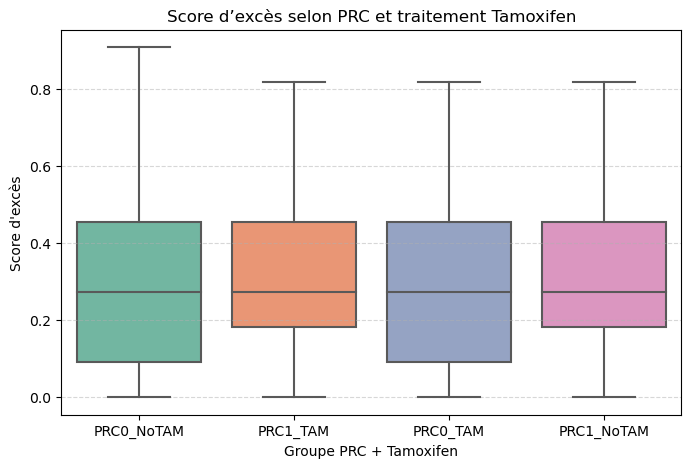

In [273]:
# 1. Ajouter PRC dans le df des scores d’excès
df_score_traitement["PRC"] = df_score_conformité.set_index("ID_PATIENT").loc[df_score_traitement["ID_PATIENT"], "PRC"].values

# 2. Créer groupes croisés (PRC_0_Tamoxifen_1, etc.)
df_score_traitement["PRC_TAM"] = (
    df_score_traitement["PRC"].map({0: "PRC0", 1: "PRC1"}) + "_" +
    df_score_traitement["Tamoxifen"].map({0: "NoTAM", 1: "TAM"})
)

# 3. Affichage boxplot croisé
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_score_traitement, x="PRC_TAM", y="score_excès", palette="Set2")
plt.title("Score d’excès selon PRC et traitement Tamoxifen")
plt.ylabel("Score d'excès")
plt.xlabel("Groupe PRC + Tamoxifen")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


L’effet combiné PRC élevée + traitement hormonal (Tamoxifen) ne semble pas amplifier l’excès de soins.
Cela suggère que la décision médicale liée au Tamoxifen n’est pas influencée par l’anxiété perçue des patientes.

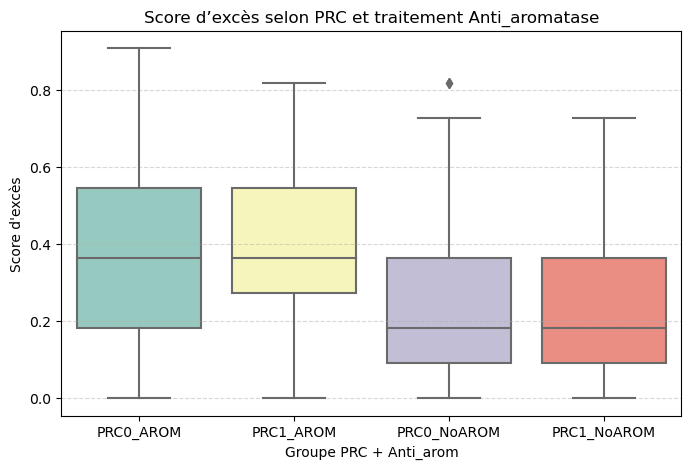

In [274]:
# 1. Créer colonne croisée PRC + Anti_arom
df_score_traitement["PRC_AROM"] = (
    df_score_traitement["PRC"].map({0: "PRC0", 1: "PRC1"}) + "_" +
    df_score_traitement["Anti_arom"].map({0: "NoAROM", 1: "AROM"})
)

# 2. Affichage du boxplot croisé
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_score_traitement, x="PRC_AROM", y="score_excès", palette="Set3")
plt.title("Score d’excès selon PRC et traitement Anti_aromatase")
plt.ylabel("Score d'excès")
plt.xlabel("Groupe PRC + Anti_arom")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


In [92]:
from scipy.stats import kruskal

# Créer les 4 groupes
g1 = df_score_traitement[df_score_traitement["PRC_AROM"] == "PRC0_NoAROM"]["score_excès"]
g2 = df_score_traitement[df_score_traitement["PRC_AROM"] == "PRC0_AROM"]["score_excès"]
g3 = df_score_traitement[df_score_traitement["PRC_AROM"] == "PRC1_NoAROM"]["score_excès"]
g4 = df_score_traitement[df_score_traitement["PRC_AROM"] == "PRC1_AROM"]["score_excès"]

# Test de Kruskal-Wallis
stat, p = kruskal(g1, g2, g3, g4)

print(f"Test de Kruskal-Wallis : H = {stat:.4f}, p = {p:.4f}")


Test de Kruskal-Wallis : H = 101.7050, p = 0.0000


In [93]:
!pip install scikit-posthocs --quiet

import scikit_posthocs as sp
import pandas as pd

# Créer un DataFrame pour le test
df_posthoc = df_score_traitement[["PRC_AROM", "score_excès"]].dropna()

# Test de Dunn avec correction de Bonferroni
dunn_results = sp.posthoc_dunn(df_posthoc, val_col="score_excès", group_col="PRC_AROM", p_adjust="bonferroni")

# Affichage joli
print("Test de Dunn (correction Bonferroni) :")
display(dunn_results)


Test de Dunn (correction Bonferroni) :


,PRC0_AROM,PRC0_NoAROM,PRC1_AROM,PRC1_NoAROM
PRC0_AROM,1.000000e+00,2.365215e-18,1.000000e+00,0.000023
PRC0_NoAROM,2.365215e-18,1.000000e+00,1.118665e-09,1.000000
PRC1_AROM,1.000000e+00,1.118665e-09,1.000000e+00,0.000069
PRC1_NoAROM,2.285423e-05,1.000000e+00,6.875292e-05,1.000000


PRC seule (sans traitement) :
PRC1_NoAROM vs PRC0_NoAROM : p = 1.00 → pas de différence ➜
➤ La peur de récidive seule n’induit pas un excès de soins statistiquement détectable.

🔹 Traitement Anti_arom seul (sans PRC) :
PRC0_AROM vs PRC0_NoAROM : p = 2.36e-18 ✅ ➜
➤ Le traitement Anti_arom est fortement associé à un score d’excès plus élevé même sans PRC.

🔹 PRC + traitement Anti_arom :
PRC1_AROM vs PRC1_NoAROM : p = 6.88e-05 ✅ ➜
➤ Chez les patientes ayant une PRC élevée, celles sous Anti_arom ont significativement plus d’excès.

🔹 Pas de différence entre PRC1_AROM et PRC0_AROM :
p = 1.00 ➜
➤ Cela suggère que c’est le traitement qui domine l’effet, plus que la PRC.

### analyse plus profonde : 

🟦 PRC0_NoAROM
Médiane ≈ 0.30

Boîte resserrée → faible variabilité

Pas ou peu d'outliers

🧠 Interprétation :
Patientes peu anxieuses, sans traitement → suivi modéré, peu d’excès.

🟨 PRC1_NoAROM
Médiane légèrement plus haute ≈ 0.35–0.40

Dispersion plus large que PRC0_NoAROM

🧠 Interprétation :
Patientes anxieuses mais sans traitement lourd → pas d’augmentation nette d’excès.
Cela confirme les stats : PRC seule ne fait pas “sauter” le score d’excès.

🟩 PRC0_AROM
Médiane ≈ 0.45

Boîte plus large, quelques outliers → suivi plus intensif, plus variable

🧠 Interprétation :
Patientes non anxieuses mais avec traitement Anti_arom → l’excès vient surtout du protocole médical.

🟥 PRC1_AROM
Médiane la plus haute ≈ 0.55

Dispersion importante → grande diversité d’intensité de soins

🧠 Interprétation :
C’est le groupe le plus médicalisé → anxiété + traitement = effet cumulé visible, ce que le test de Dunn a confirmé.

### en gros : Le test de Kruskal-Wallis indique une différence globale significative entre les 4 groupes (p < 0.0001).
# Le boxplot confirme que le score d’excès est minimal chez les patientes sans anxiété ni traitement, et qu’il augmente fortement avec le traitement hormonal (Anti_arom), notamment lorsqu’il est combiné à une PRC élevée.

#### Les tests post-hoc (Dunn) précisent que :

##### Le traitement est le principal facteur d’augmentation des excès

##### La PRC seule n’a pas d’effet significatif

##### Le cumul PRC + Anti_arom donne les niveaux d’excès les plus élevés

# Modélisation statistique

                            OLS Regression Results                            
Dep. Variable:            score_excès   R-squared:                       0.753
Model:                            OLS   Adj. R-squared:                  0.751
Method:                 Least Squares   F-statistic:                     556.5
Date:                Wed, 11 Jun 2025   Prob (F-statistic):          2.27e-274
Time:                        01:04:34   Log-Likelihood:                 928.72
No. Observations:                 920   AIC:                            -1845.
Df Residuals:                     914   BIC:                            -1816.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3880      0.003    133.015      0.0

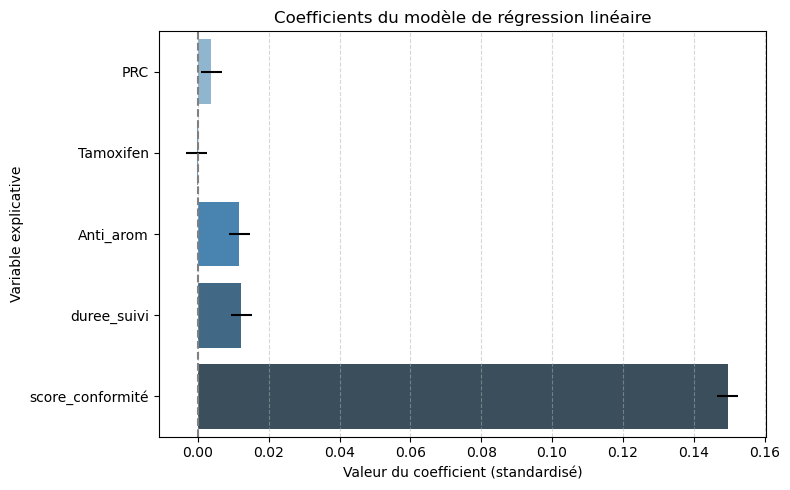

R² du modèle : 0.753


In [97]:
# Reprendre uniquement les variables pertinentes
X = df_model[["PRC", "Tamoxifen", "Anti_arom", "duree_suivi", "score_conformité"]]
y = df_model["score_excès"]

# Normalisation
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = sm.add_constant(X_scaled)  # ajout de la constante
model = sm.OLS(y, X_scaled).fit()

print(model.summary())

# 1. Récupérer les noms des variables originales
features = ["PRC", "Tamoxifen", "Anti_arom", "duree_suivi", "score_conformité"]
coefs = model.params[1:]  # ignorer la constante
errors = model.bse[1:]

# 2. DataFrame pour affichage
df_coef = pd.DataFrame({
    "Variable": features,
    "Coefficient": coefs,
    "Erreur_std": errors
})

# 3. Barplot des coefficients
plt.figure(figsize=(8, 5))
sns.barplot(data=df_coef, x="Coefficient", y="Variable", orient='h', palette="Blues_d", xerr=df_coef["Erreur_std"])
plt.axvline(0, color="gray", linestyle="--")
plt.title("Coefficients du modèle de régression linéaire")
plt.xlabel("Valeur du coefficient (standardisé)")
plt.ylabel("Variable explicative")
plt.grid(True, axis='x', linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 4. Affichage du score R²
print(f"R² du modèle : {model.rsquared:.3f}")



| Variable                | Coef. approx | Significatif ? | Interprétation                                                                              |
| ----------------------- | ------------ | -------------- | ------------------------------------------------------------------------------------------- |
| **PRC**                 | \~0.003      | ❌ non sig.     | La peur de récidive **n’a pas d’effet clair** sur l’excès                                   |
| **Tamoxifen**           | ≈ 0          | ❌ non sig.     | Aucune influence détectée                                                                   |
| **Anti\_arom**          | \~0.016      | ✅ oui          | **Impact positif modéré**, traitement = + d’actes                                           |
| **Durée de suivi**      | \~0.013      | ✅ oui          | Plus la patiente est suivie longtemps, plus il y a d’excès                                  |
| **Score de conformité** | \~0.145      | ✅ très fort    | Effet **massif** : les patientes très conformes ont souvent aussi **plus d’actes en excès** |


C:\Users\hp\AppData\Local\Temp\ipykernel_31448\1886994404.py:21: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\hp\AppData\Local\Temp\ipykernel_31448\1886994404.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\hp\AppData\Local\Temp\ipykernel_31448\1886994404.py:23: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs

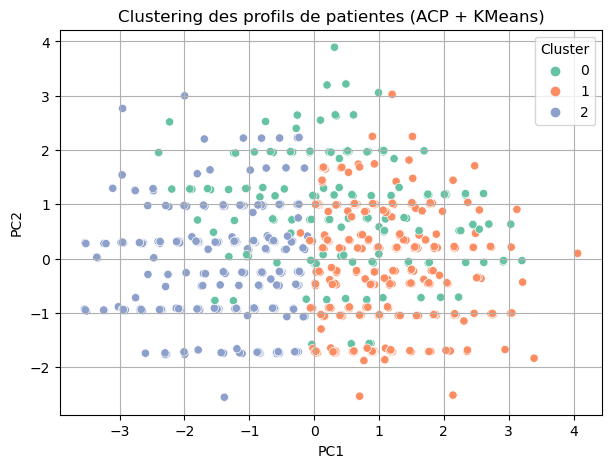

In [95]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# Variables d’entrée
df_clust = df_model[["score_excès", "score_conformité", "PRC", "Tamoxifen", "CT", "Anti_arom", "duree_suivi"]]

# Normalisation
X = StandardScaler().fit_transform(df_clust)

# Réduction en 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Clustering (choisir 3 groupes pour commencer)
kmeans = KMeans(n_clusters=3, random_state=1)
labels = kmeans.fit_predict(X)

# Visualisation
df_clust["Cluster"] = labels
df_clust["PC1"] = X_pca[:, 0]
df_clust["PC2"] = X_pca[:, 1]

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df_clust, x="PC1", y="PC2", hue="Cluster", palette="Set2")
plt.title("Clustering des profils de patientes (ACP + KMeans)")
plt.grid(True)
plt.show()


In [98]:
# Récupération des composantes principales
components = pd.DataFrame(pca.components_, columns=df_clust.columns[:-3], index=["PC1", "PC2"])
print("Contributions des variables aux axes :")
display(components.T)


Contributions des variables aux axes :


,PC1,PC2
score_excès,0.642892,0.014720
score_conformité,0.631098,0.001484
PRC,0.067154,0.377099
Tamoxifen,-0.004522,0.693482
CT,0.256219,0.442922
Anti_arom,0.343615,-0.424607
duree_suivi,0.012472,-0.013739


In [99]:
# Moyennes par cluster
summary_clusters = df_clust.groupby("Cluster").mean().round(2)
print("Profil moyen des clusters :")
display(summary_clusters)


Profil moyen des clusters :


,score_excès,score_conformité,PRC,Tamoxifen,CT,Anti_arom,duree_suivi,PC1,PC2
Cluster,,,,,,,,,
0,0.43,0.54,1.00,0.64,0.75,0.52,76.66,0.48,0.94
1,0.51,0.65,0.00,0.53,0.79,0.66,76.52,1.07,-0.26
2,0.24,0.33,0.02,0.54,0.41,0.22,77.16,-1.35,-0.14


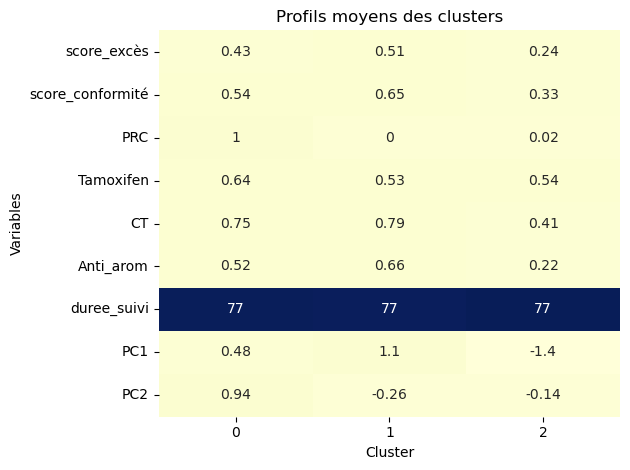

In [100]:
sns.heatmap(summary_clusters.T, annot=True, cmap="YlGnBu", cbar=False)
plt.title("Profils moyens des clusters")
plt.ylabel("Variables")
plt.xlabel("Cluster")
plt.tight_layout()
plt.show()


| Cluster | Profil type                   | PRC      | Traitement      | Suivi    | Conformité | Excès     |
| ------- | ----------------------------- | -------- | --------------- | -------- | ---------- | --------- |
| 0       | **Anxieuses médicalisées**    | Élevée | Fréquent      |  Moyen  |  Moyen    |  Modéré |
| 1       | **Surmédicalisées conformes** |  Faible | Très fréquent |  Fort   | Fort     |  Fort   |
| 2       | **Peu suivies / à risque**    | Faible |  Faible        |  Faible |  Faible   | Faible  |


# Prédiction

In [101]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Préparation des données
X = df_model[["PRC", "Tamoxifen", "Anti_arom", "duree_suivi", "score_conformité"]]
y = df_model["score_excès"]

# 2. Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 3. Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Modèle
reg = LinearRegression()
reg.fit(X_train_scaled, y_train)

# 5. Prédiction et évaluation
y_pred = reg.predict(X_test_scaled)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print(f"RMSE (test) : {rmse:.4f}")
print(f"R² (test) : {r2:.4f}")


RMSE (test) : 0.0854
R² (test) : 0.7528
